In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "NUHOR"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[20:23, 4] = 1
    file["BADPIX"].data[12:15, -5] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    # if file[0].header["TARGPROP"] == "TD-PDS-70":
    #     # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    #     file["BADPIX"].data[17, 70] = 1
    #     file["BADPIX"].data[19, 53] = 1
    #     file["BADPIX"].data[5, 22] = 1
    #     file["BADPIX"].data[19, 41] = 1
    #     # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
    #     file["BADPIX"].data[76, 45] = 1
    #     file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        # file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

HD-18638 F480M, Dither 1/1, Roll 351.0deg, 49.0min, 2023-10-31 11:45:42.890, Groups: 8, Ints: 4869, PWCPOS 204.99400000000333
HD-18638 F430M, Dither 1/1, Roll 351.0deg, 39.3min, 2023-10-31 12:40:30.453, Groups: 5, Ints: 6256, PWCPOS 204.99400000000287
NU-HOR F480M, Dither 1/1, Roll 353.1deg, 30.0min, 2023-10-31 13:58:16.590, Groups: 5, Ints: 4766, PWCPOS 204.994
NU-HOR F430M, Dither 1/1, Roll 353.1deg, 26.6min, 2023-10-31 14:37:34.322, Groups: 3, Ints: 7041, PWCPOS 204.994


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [5]:
from dorito.models import ResolvedAmigoModel
from dorito.model_fits import PointResolvedFit
from amigo.model_fits import ModelFit


class ExoZodiFit(PointResolvedFit):
    """
    Model fit for resolved sources. This adds the log distribution parameter.
    """

    def get_key(self, param):

        match param:
            case "stdev":
                return self.filter

        return super().get_key(param)

    def map_param(self, param):

        # Map the appropriate parameter to the correct key
        if param in ["stdev"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return super().map_param(param)

    def initialise_params(self, optics, stdev, contrast):
        """
        Initialise the parameters for the resolved source model fit.
        The log distribution is set to a uniform distribution specified by the source size.

        Args:
            optics: The optics object (to pass to the parent class).
            source_size: The size of the source distribution (assumed square).

        Returns:
            params: A dictionary containing the initialised parameters for the model fit.
        """

        params = ModelFit.initialise_params(self, optics)

        # log distribution
        params["stdev"] = (self.get_key("stdev"), stdev)
        params["contrast"] = self.get_key("contrast"), np.array(contrast)

        return params


class ExoZodiModel(ResolvedAmigoModel):

    size: int = None

    def __init__(
        self,
        exposures,
        optics,
        detector,
        ramp_model,
        read,
        state,
        size,
        rotate=True,
        source_oversample=1,
        param_initers=None,
    ):
        self.size = size
        super().__init__(
            exposures,
            optics,
            detector,
            ramp_model,
            read,
            state,
            rotate,
            source_oversample,
            param_initers,
        )

    @staticmethod
    def gaussian2d(npix, sigma):
        c = (npix - 1) / 2
        x = np.arange(npix)
        gx = jax.scipy.stats.norm.pdf(x, loc=c, scale=sigma)
        g = np.outer(gx, gx)
        return g / np.sum(g)

    def get_distribution(self, exposure, rotate=None, source_id=None):

        stdev = self.params["stdev"][exposure.get_key("stdev")]
        distribution = self.gaussian2d(self.size, stdev)

        return distribution

In [8]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
sci_exps = [ExoZodiFit(file) for file in sci_files]
cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files]
exps = sci_exps + cal_exps

# building the model
source_size = 15  # pixels

model = ExoZodiModel(
    size=source_size,
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    param_initers={"contrast": np.array(1e-5), "stdev": np.array(1)},
)

# model.params["aberrations"] = load_dict("files/NUHOR_CAL.npy")["aberrations"]
model = model.set("params", load_dict(f"files/NUHOR_CAL.npy"))

File 01242_009_02_03_1
Star NU-HOR
Filter F480M
nints 4766
ngroups 5



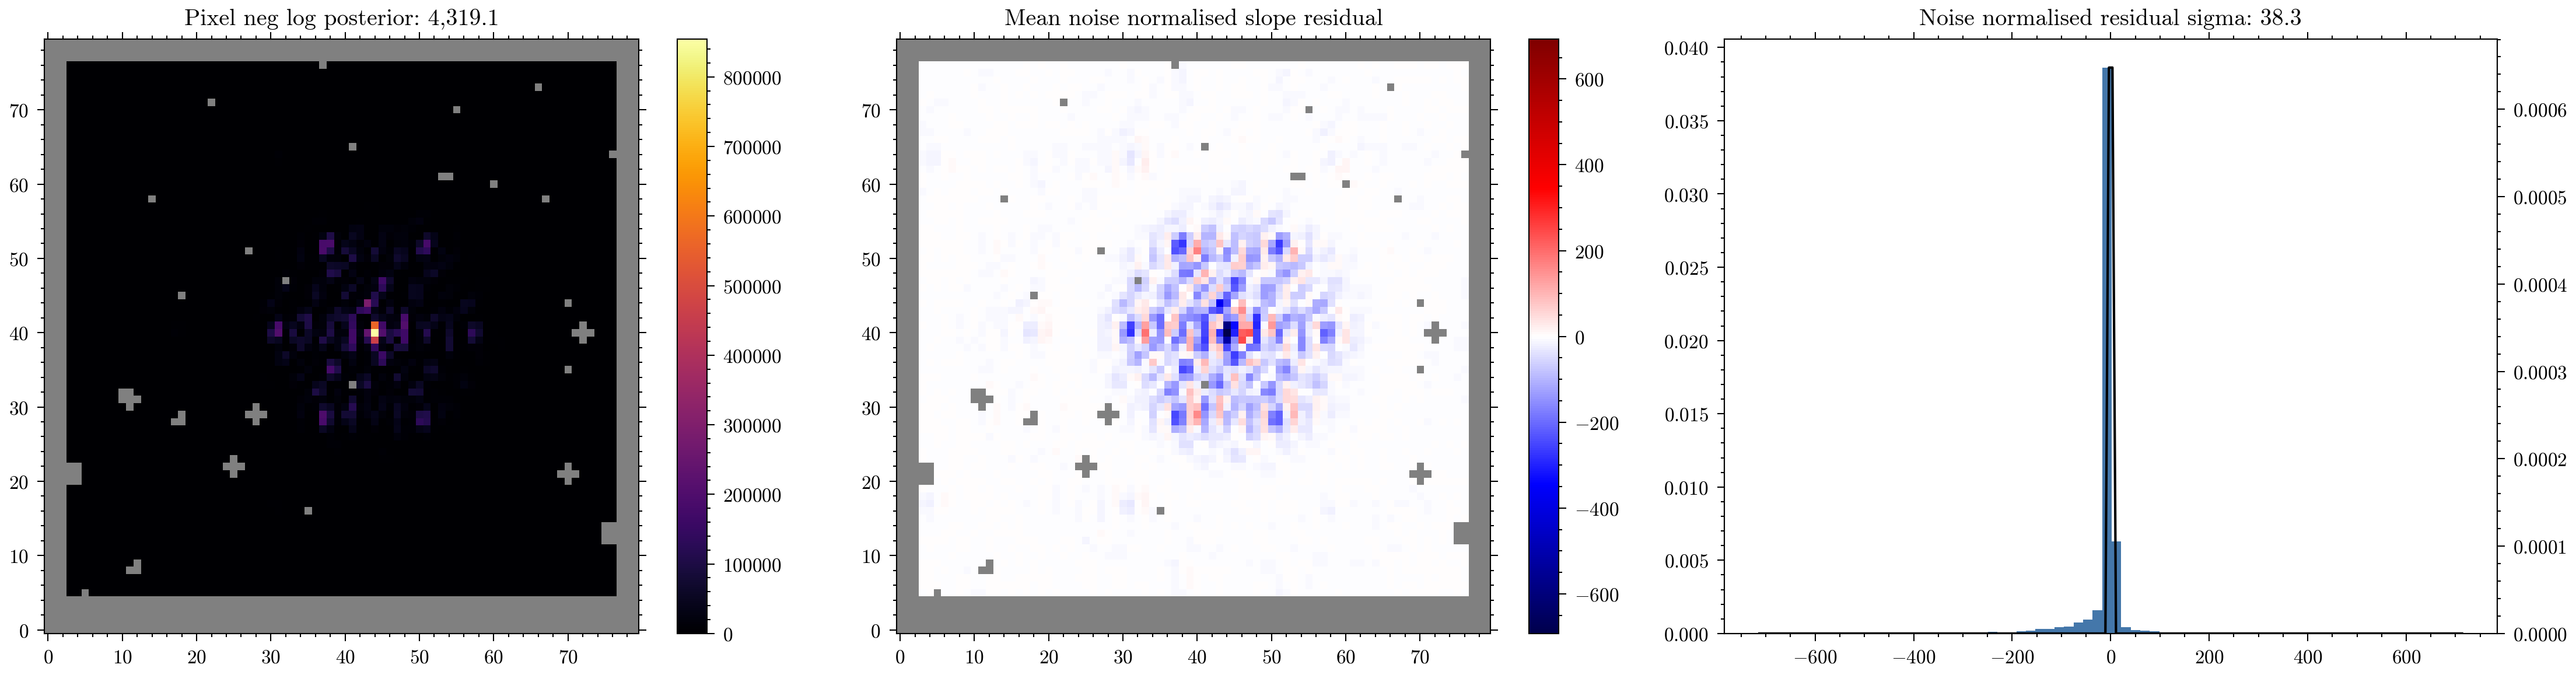

File 01242_009_04_03_1
Star NU-HOR
Filter F430M
nints 7041
ngroups 3



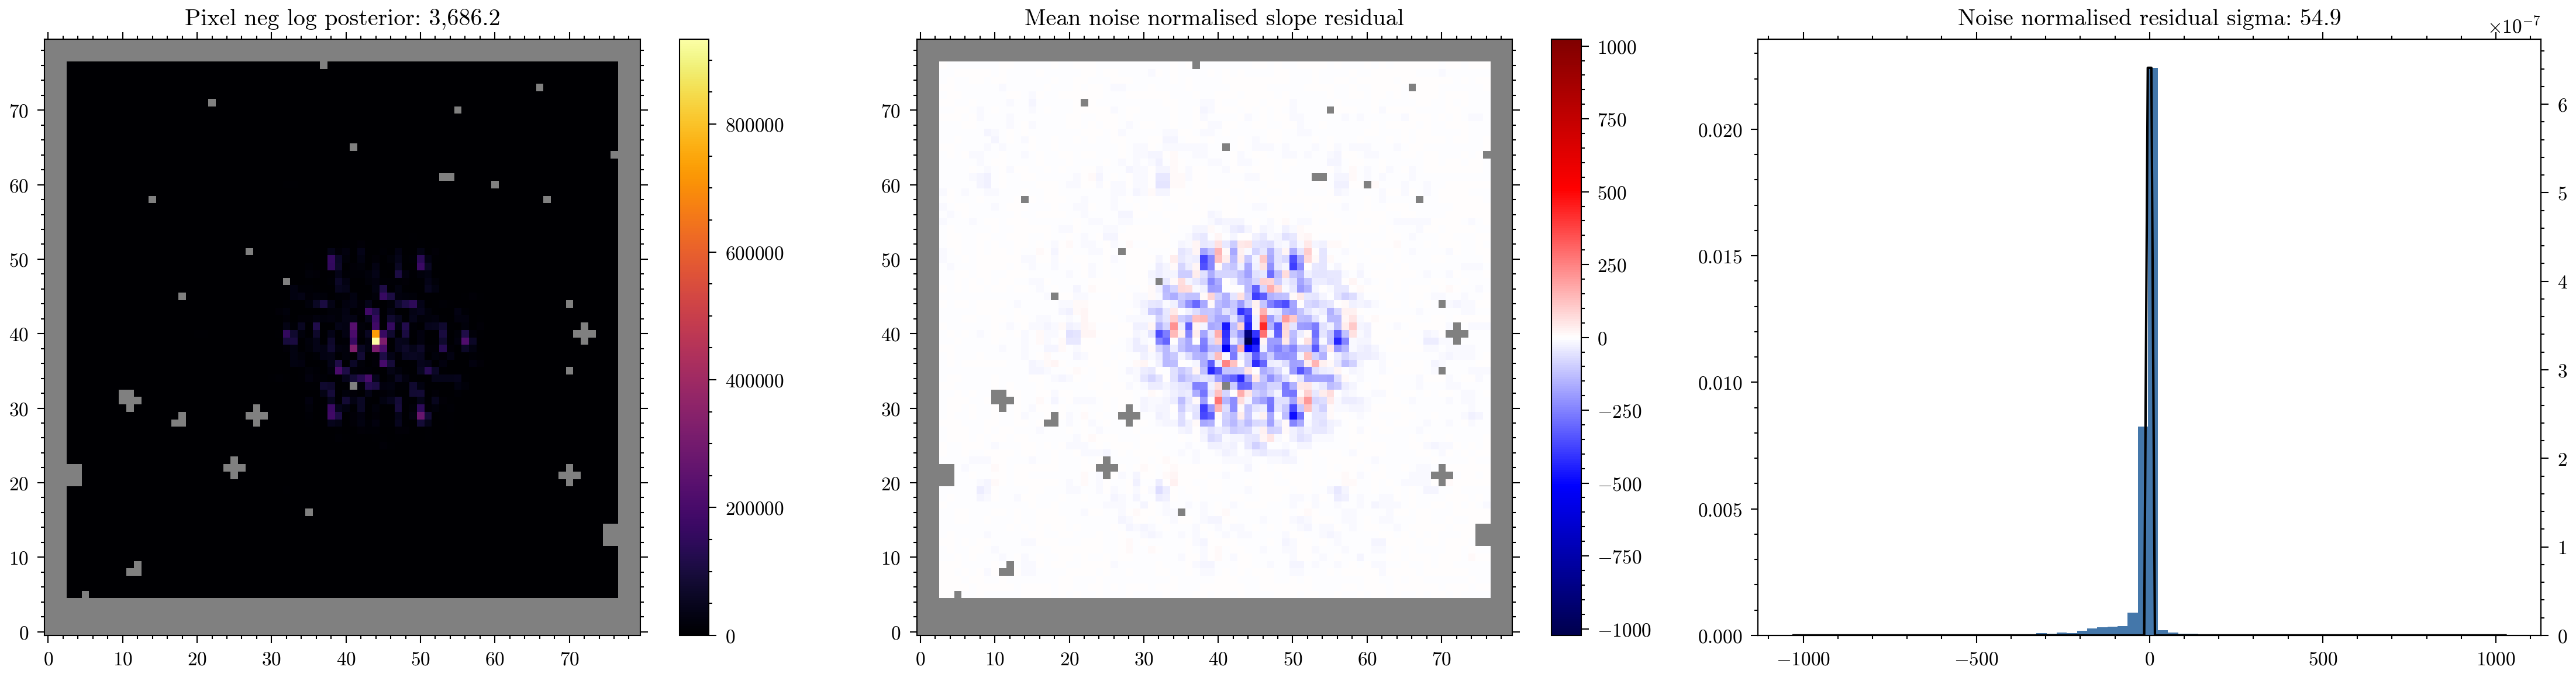

File 01242_010_02_03_1
Star HD-18638
Filter F480M
nints 4869
ngroups 8



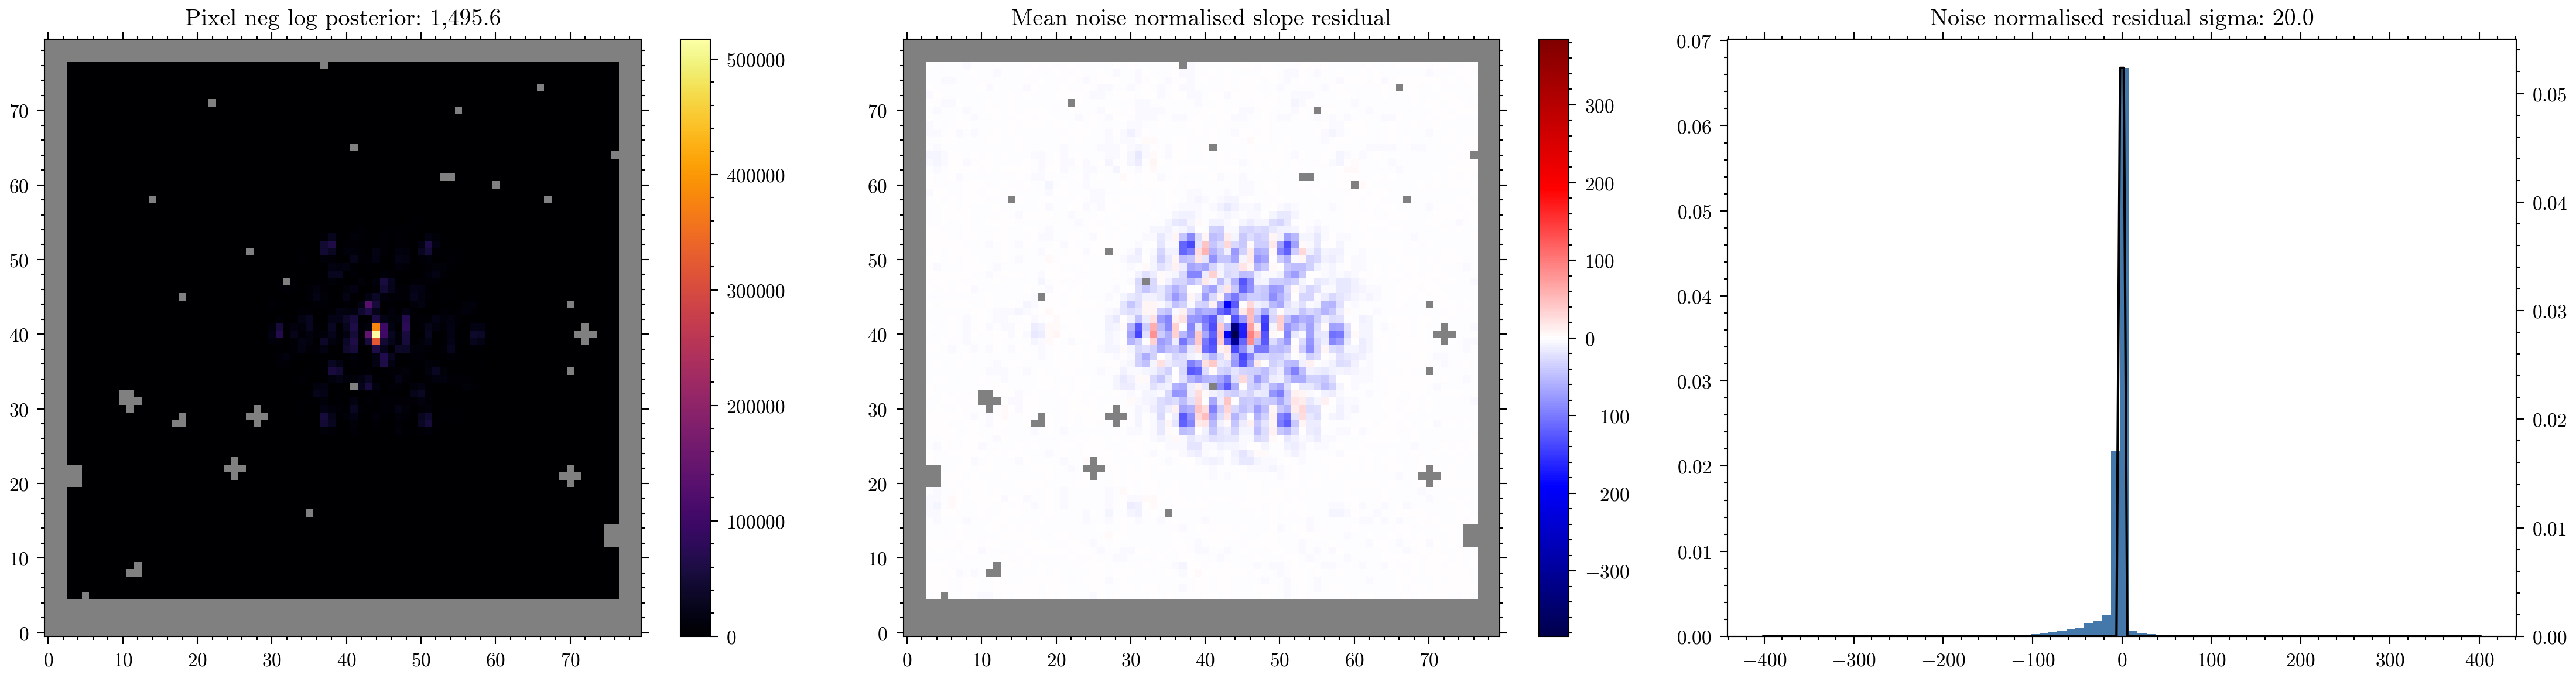

File 01242_010_04_03_1
Star HD-18638
Filter F430M
nints 6256
ngroups 5



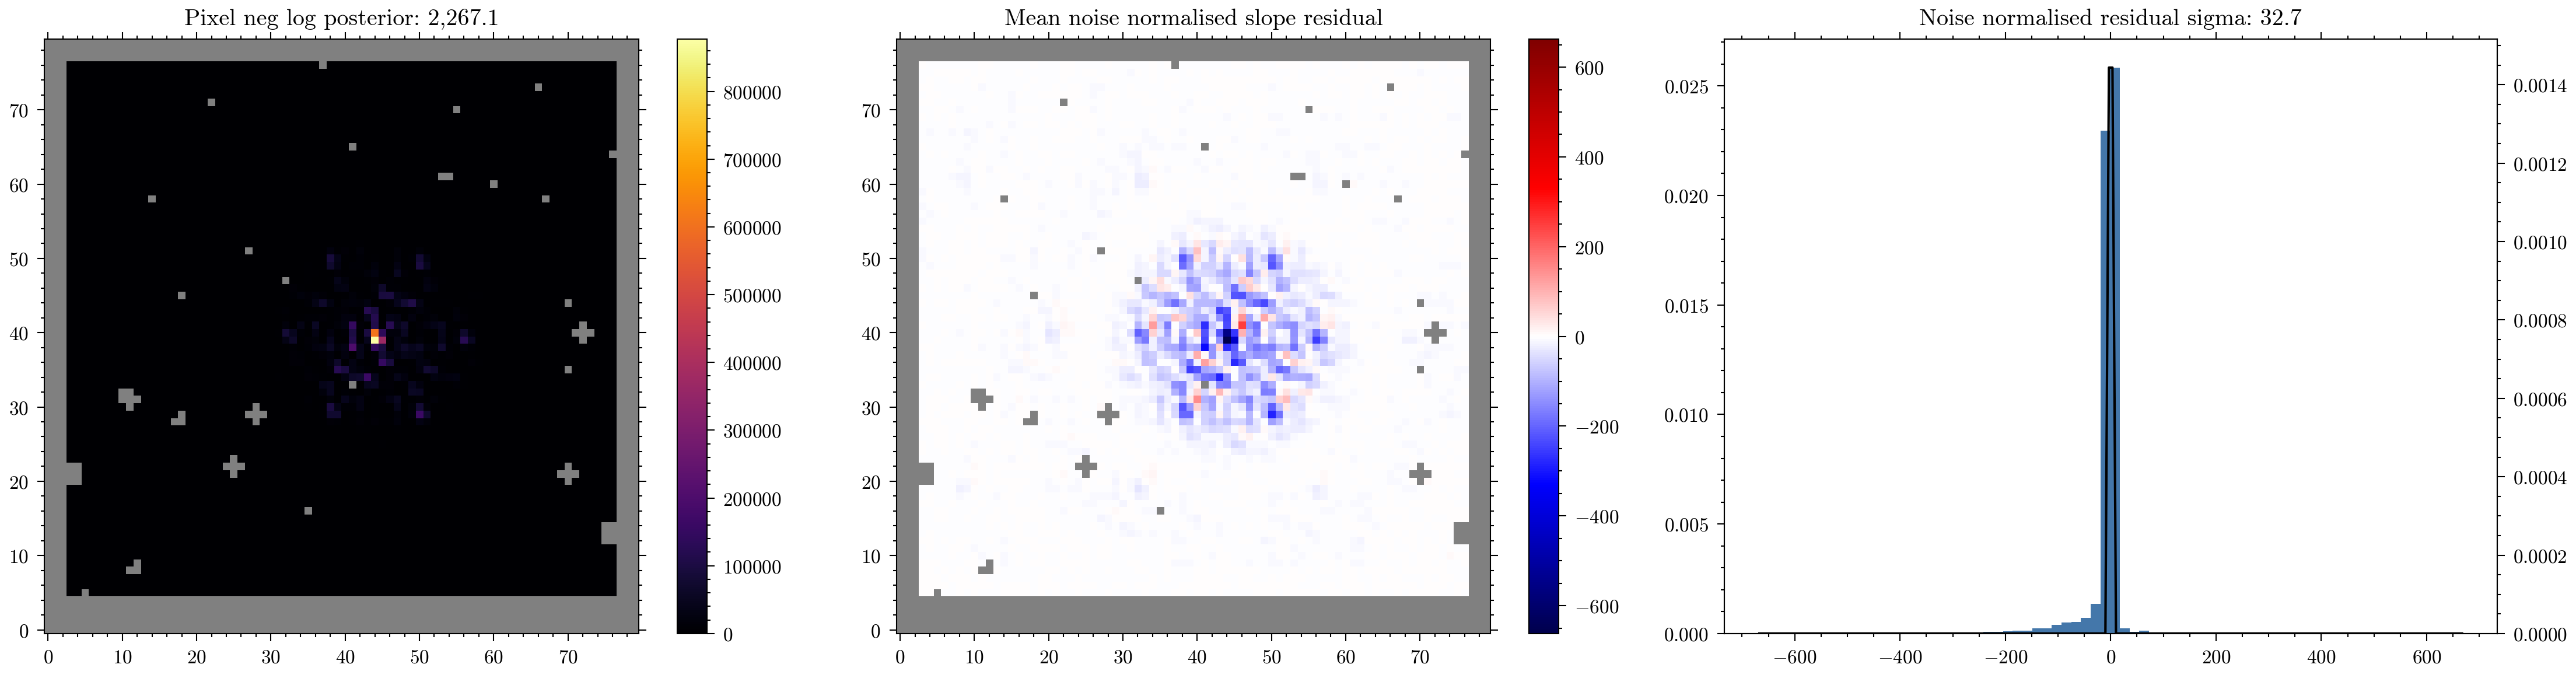

In [10]:
for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

In [8]:
n_epoch = 100

config = {
    "positions": sgd(3e-1, 0, (50, 0)),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(1e-1, 4),
    "spectra": sgd(4e-1, 8),
    # "contrast": sgd(2e-6, 20),
    # "stdev": sgd(2e-3, 15),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["stdev", "contrast"]],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
)

Populating fishers...
Number of exposures:  4


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 2,946.38
Estimated run time: 0:02:43
Full Time: 0:03:25
Final Loss: 17.46


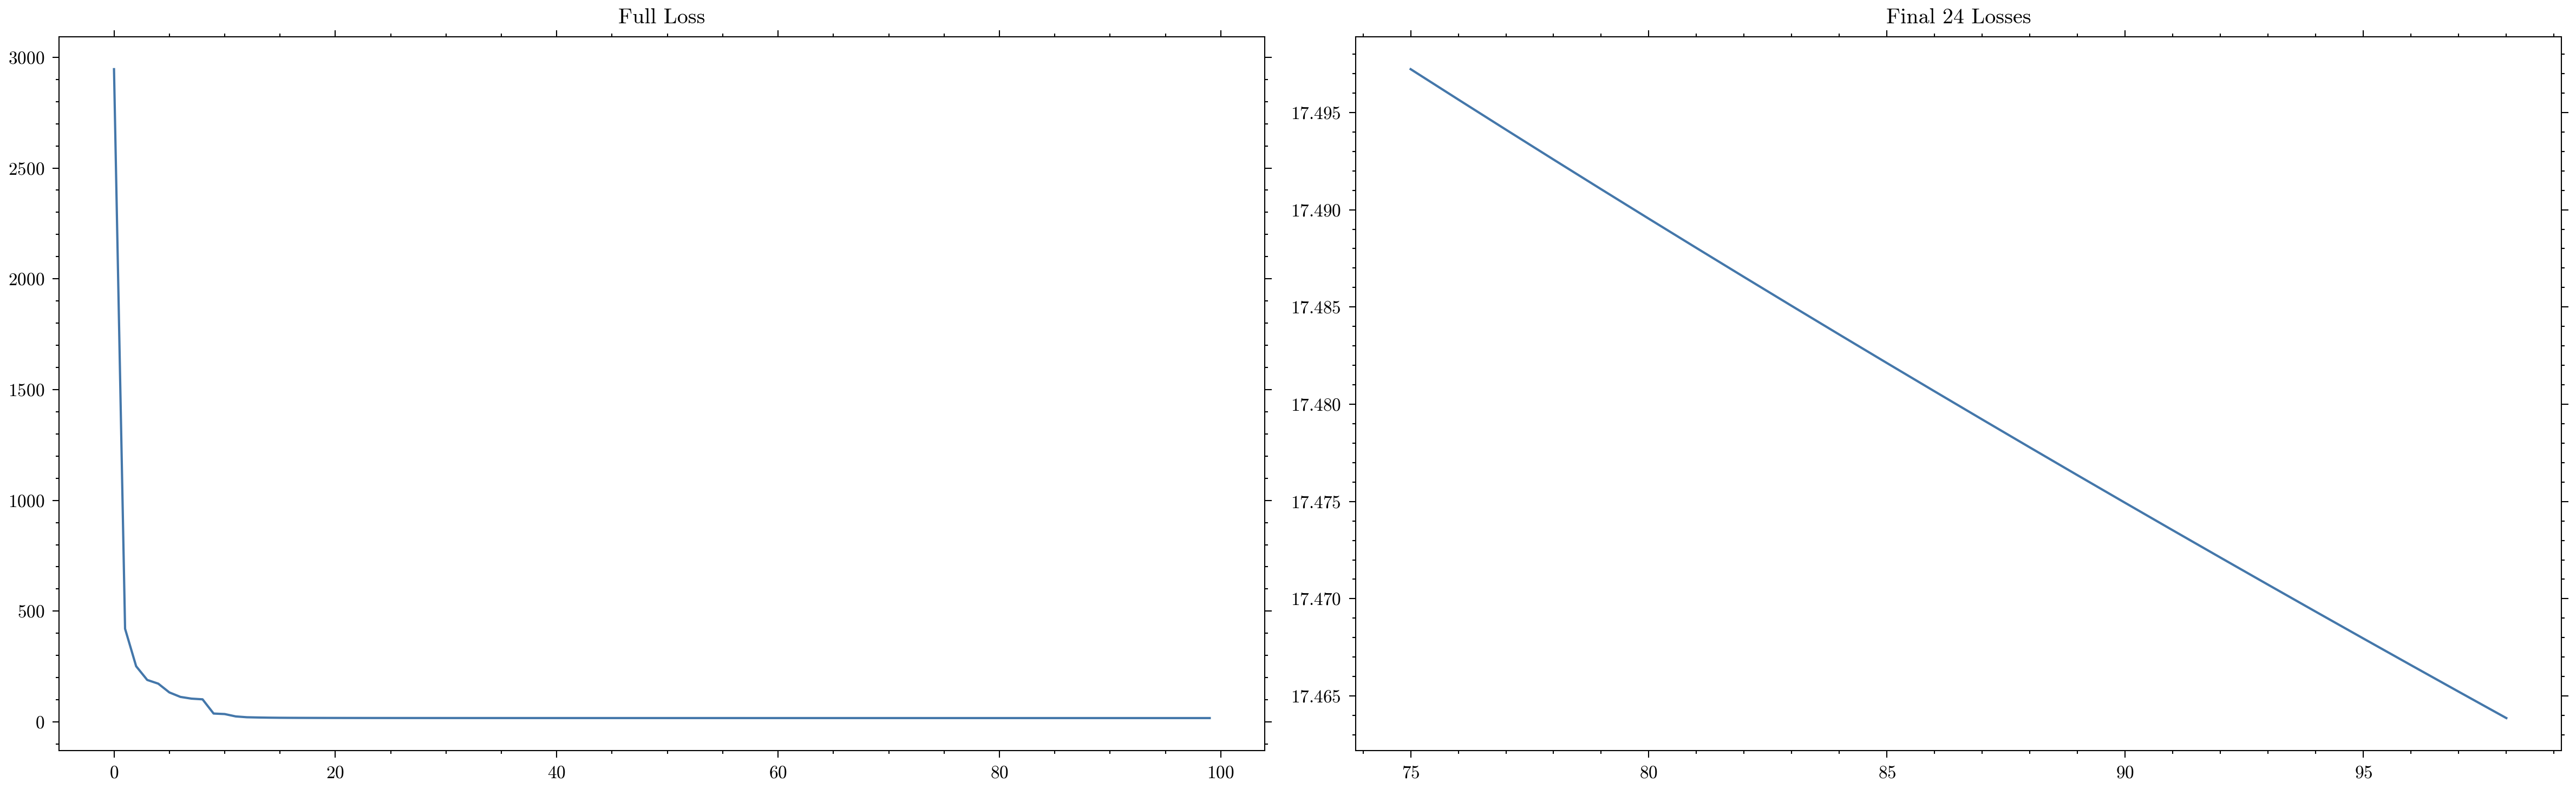

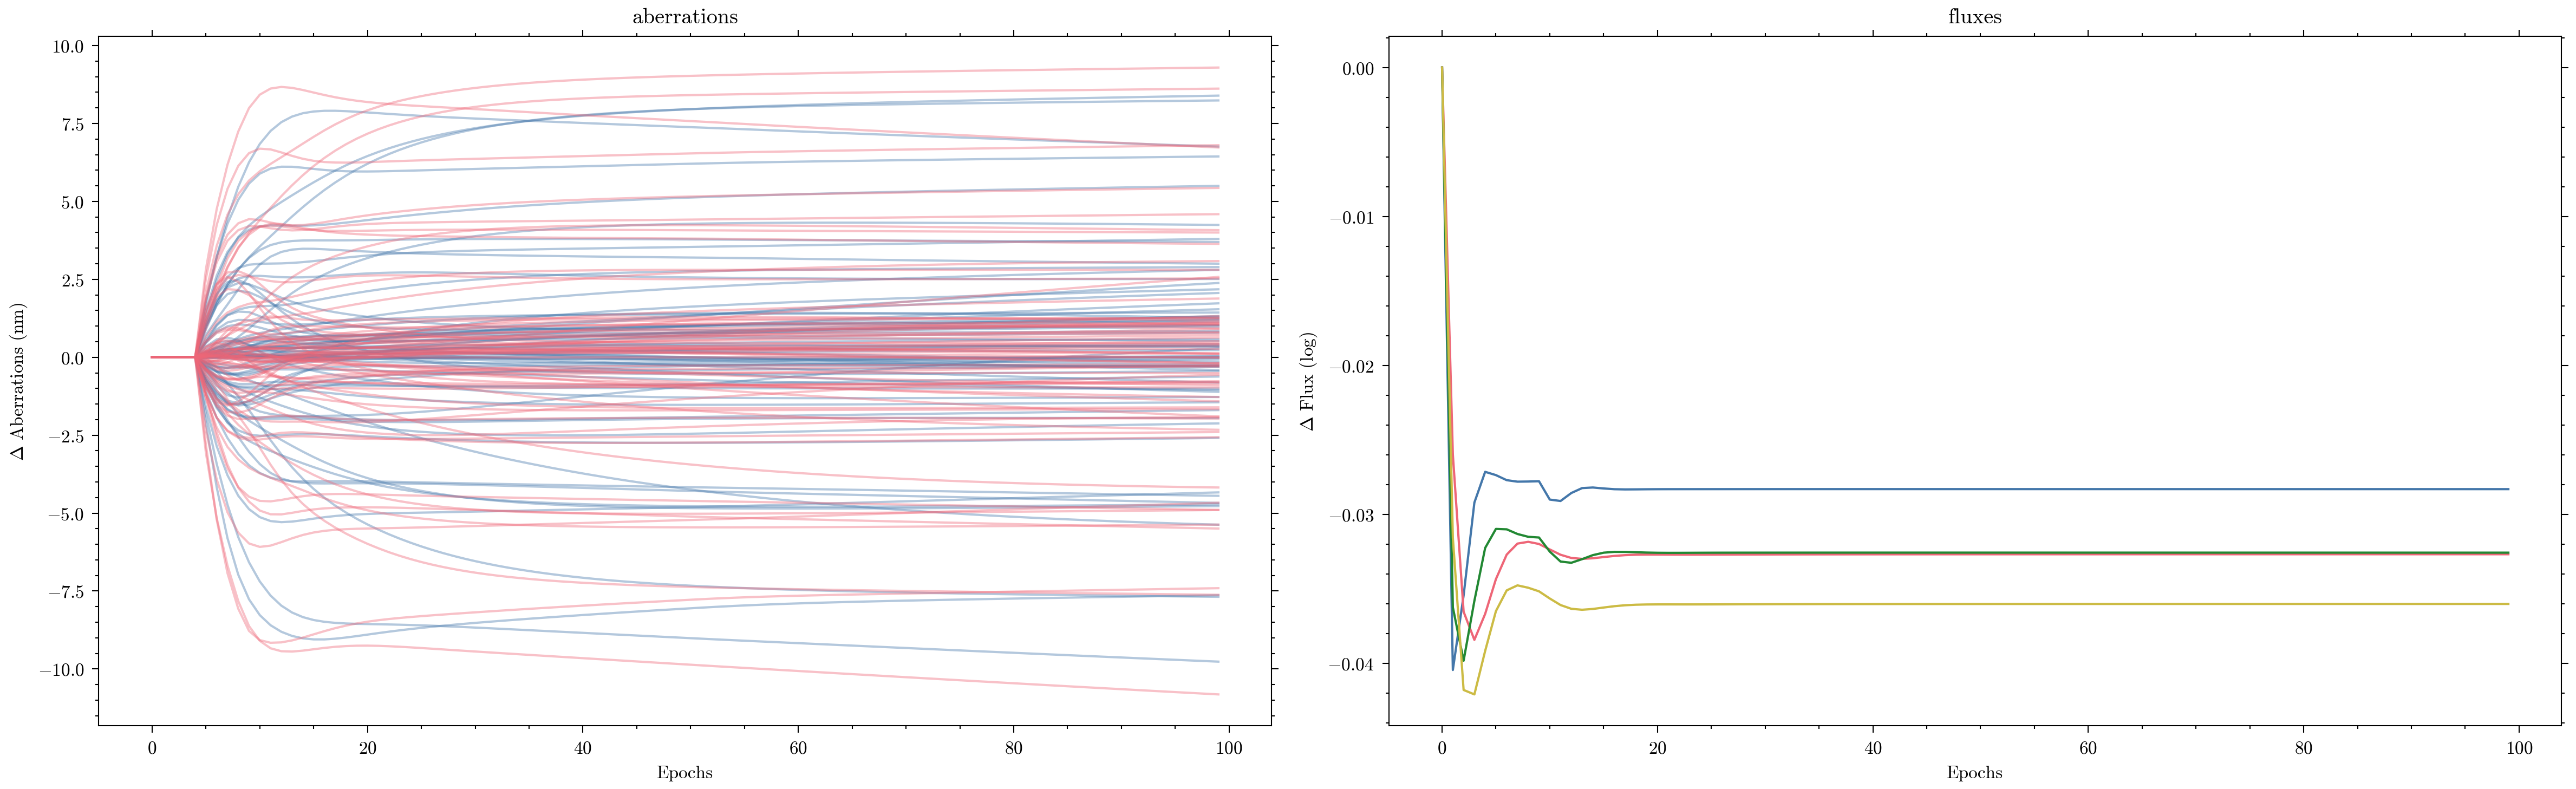

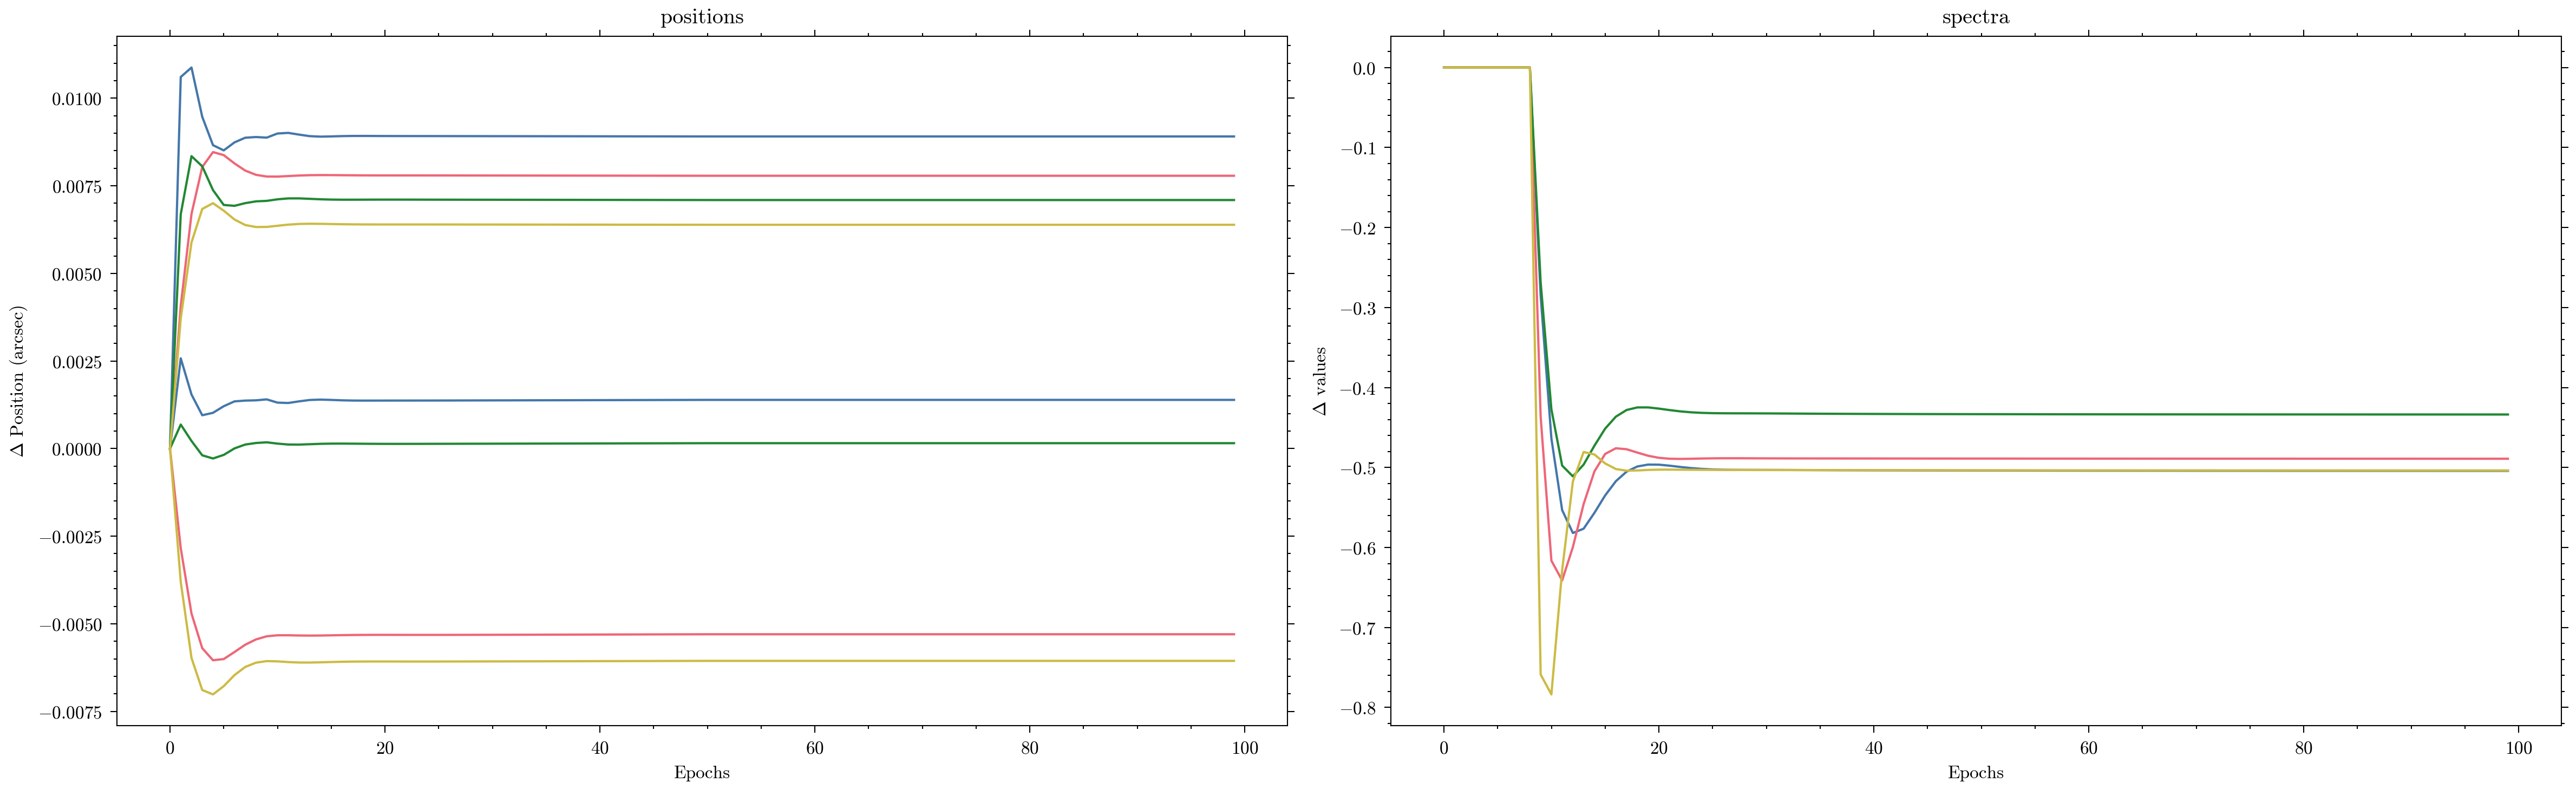

File 01242_009_02_03_1
Star NU-HOR
Filter F480M
nints 4766
ngroups 5



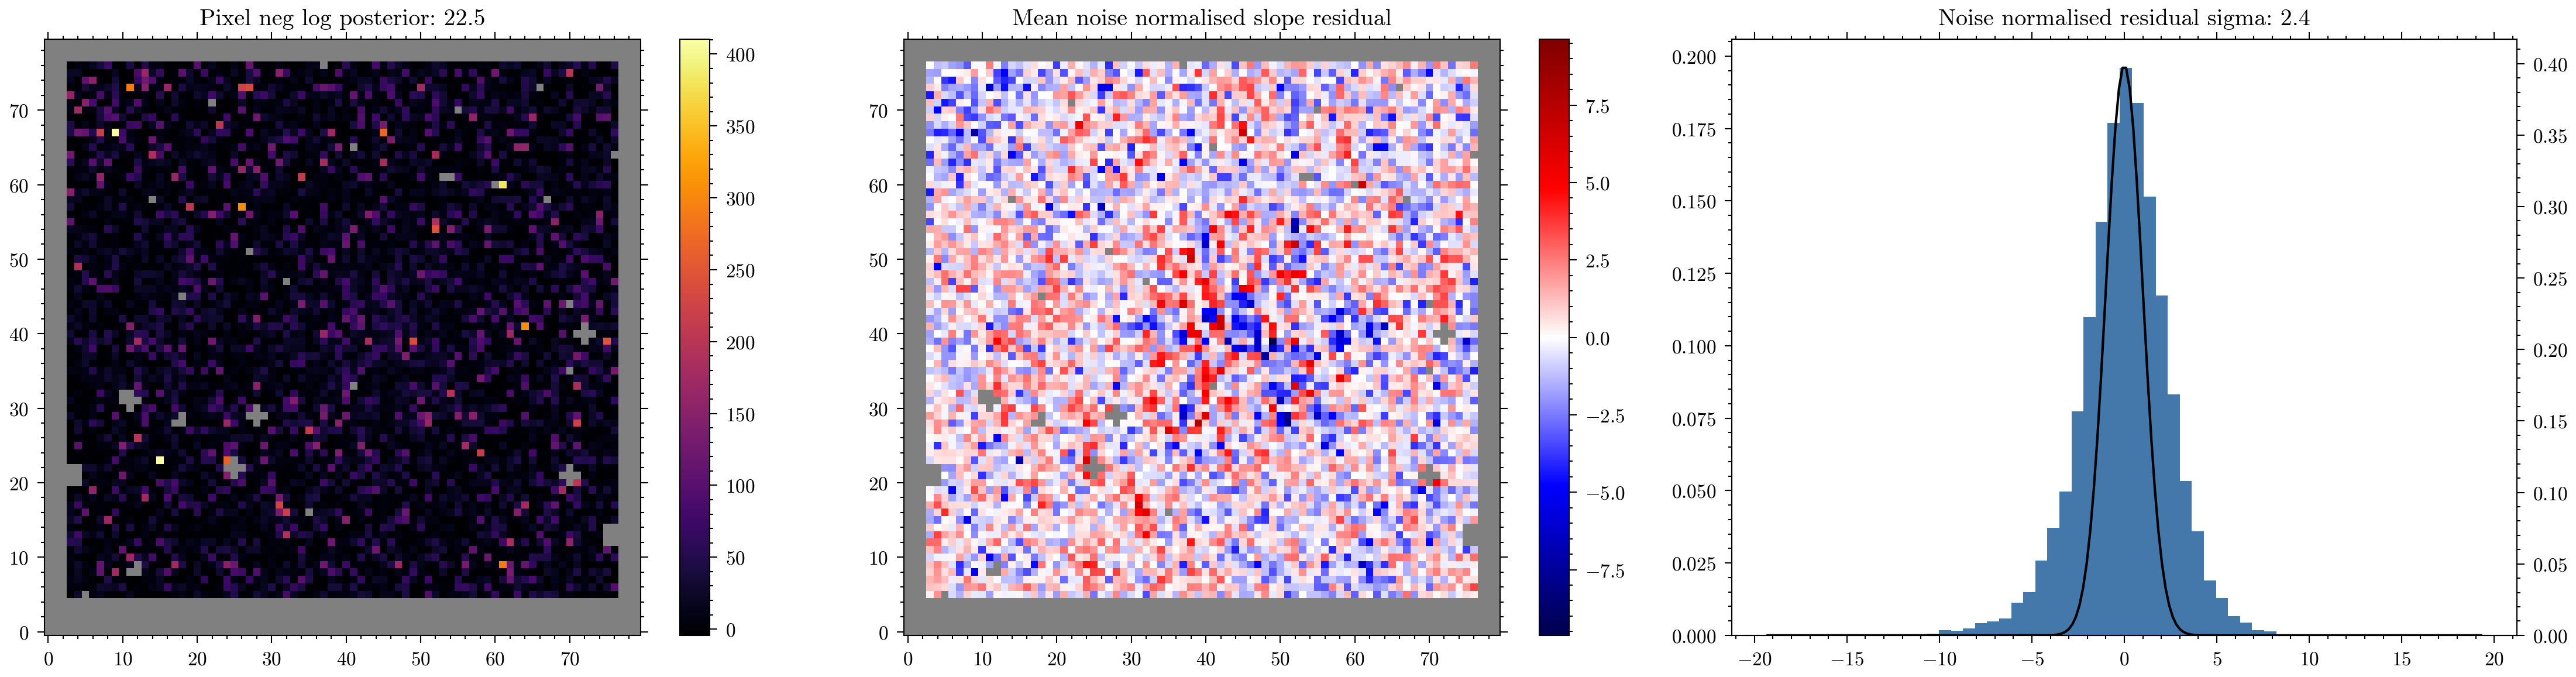

File 01242_009_04_03_1
Star NU-HOR
Filter F430M
nints 7041
ngroups 3



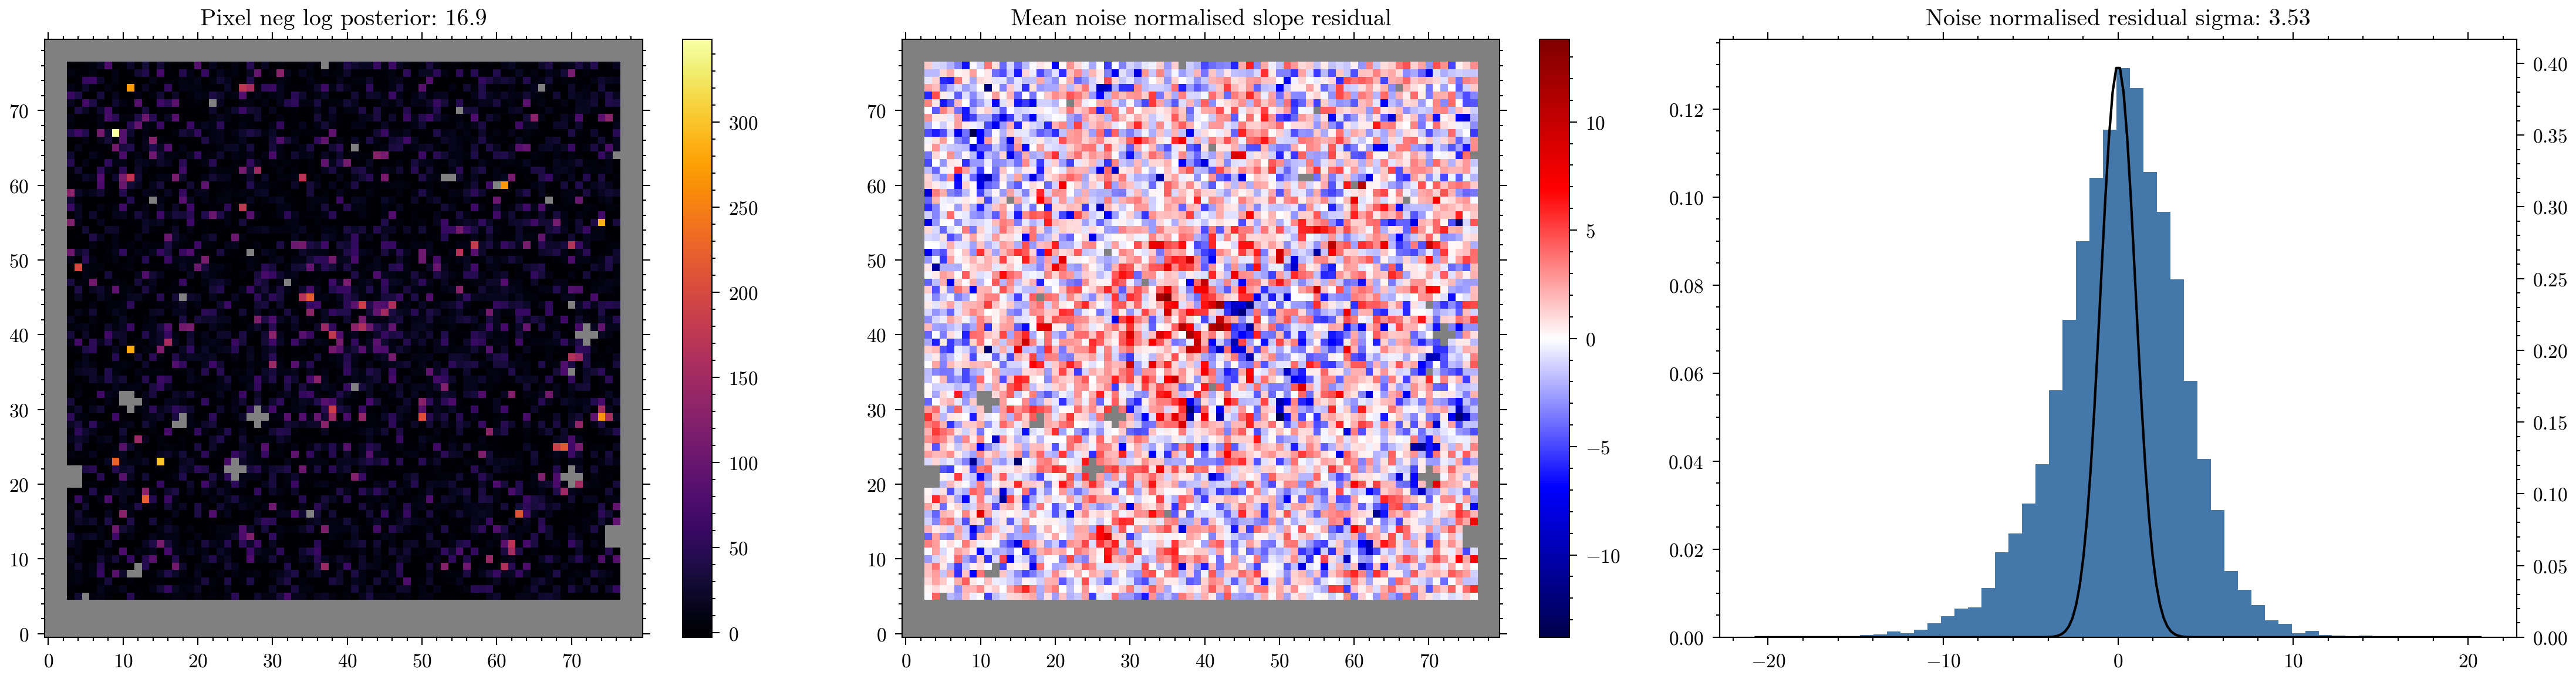

File 01242_010_02_03_1
Star HD-18638
Filter F480M
nints 4869
ngroups 8



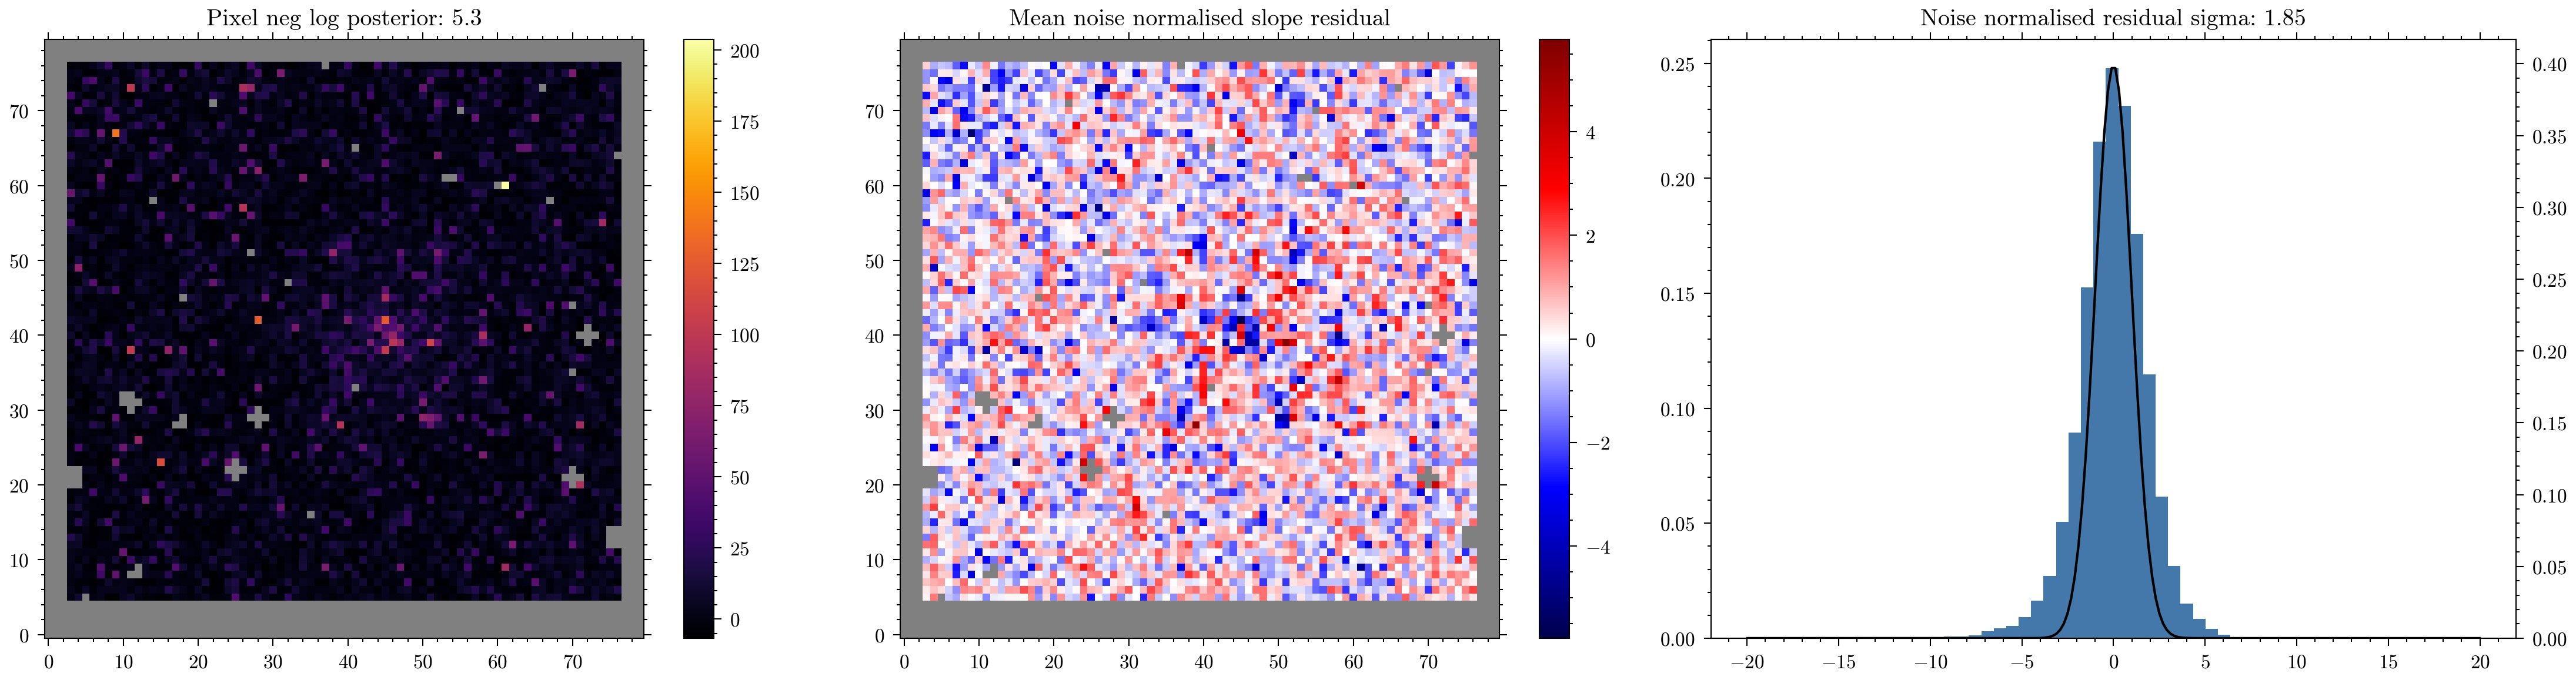

File 01242_010_04_03_1
Star HD-18638
Filter F430M
nints 6256
ngroups 5



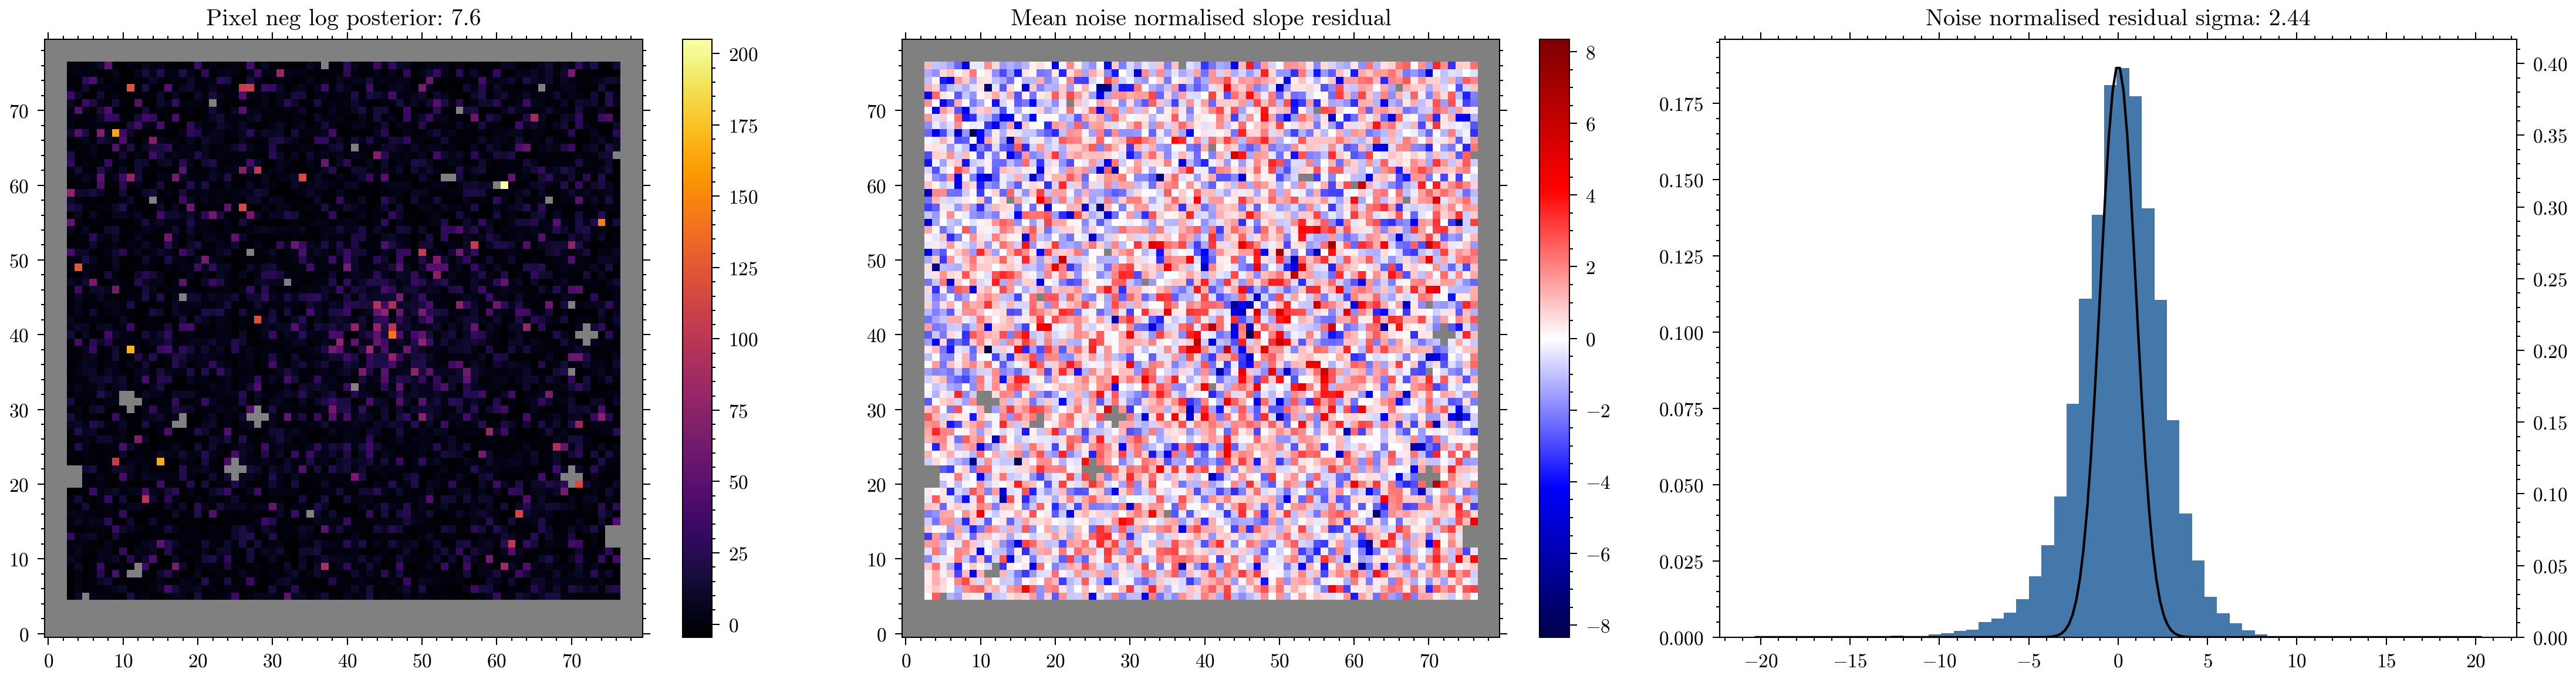

In [9]:
# np.save("NUHOR_CAL.npy", result.model.params, allow_pickle=True)
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

# BFGS

In [15]:
# break

import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = [
    "aberrations",
    "fluxes",
    "spectra",
]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exps:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}", e)
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 26.62423096117968
Final loss: 26.624230958185755
7 5


Initial loss: 19.26737027492706
Final loss: 19.267370266953602
6 6


Initial loss: 12.025082626969999
Final loss: 11.895150853114295
272 215


Initial loss: 11.92801694939403
Final loss: 11.735654944447335
257 216




In [16]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

F430M Science NU-HOR 3


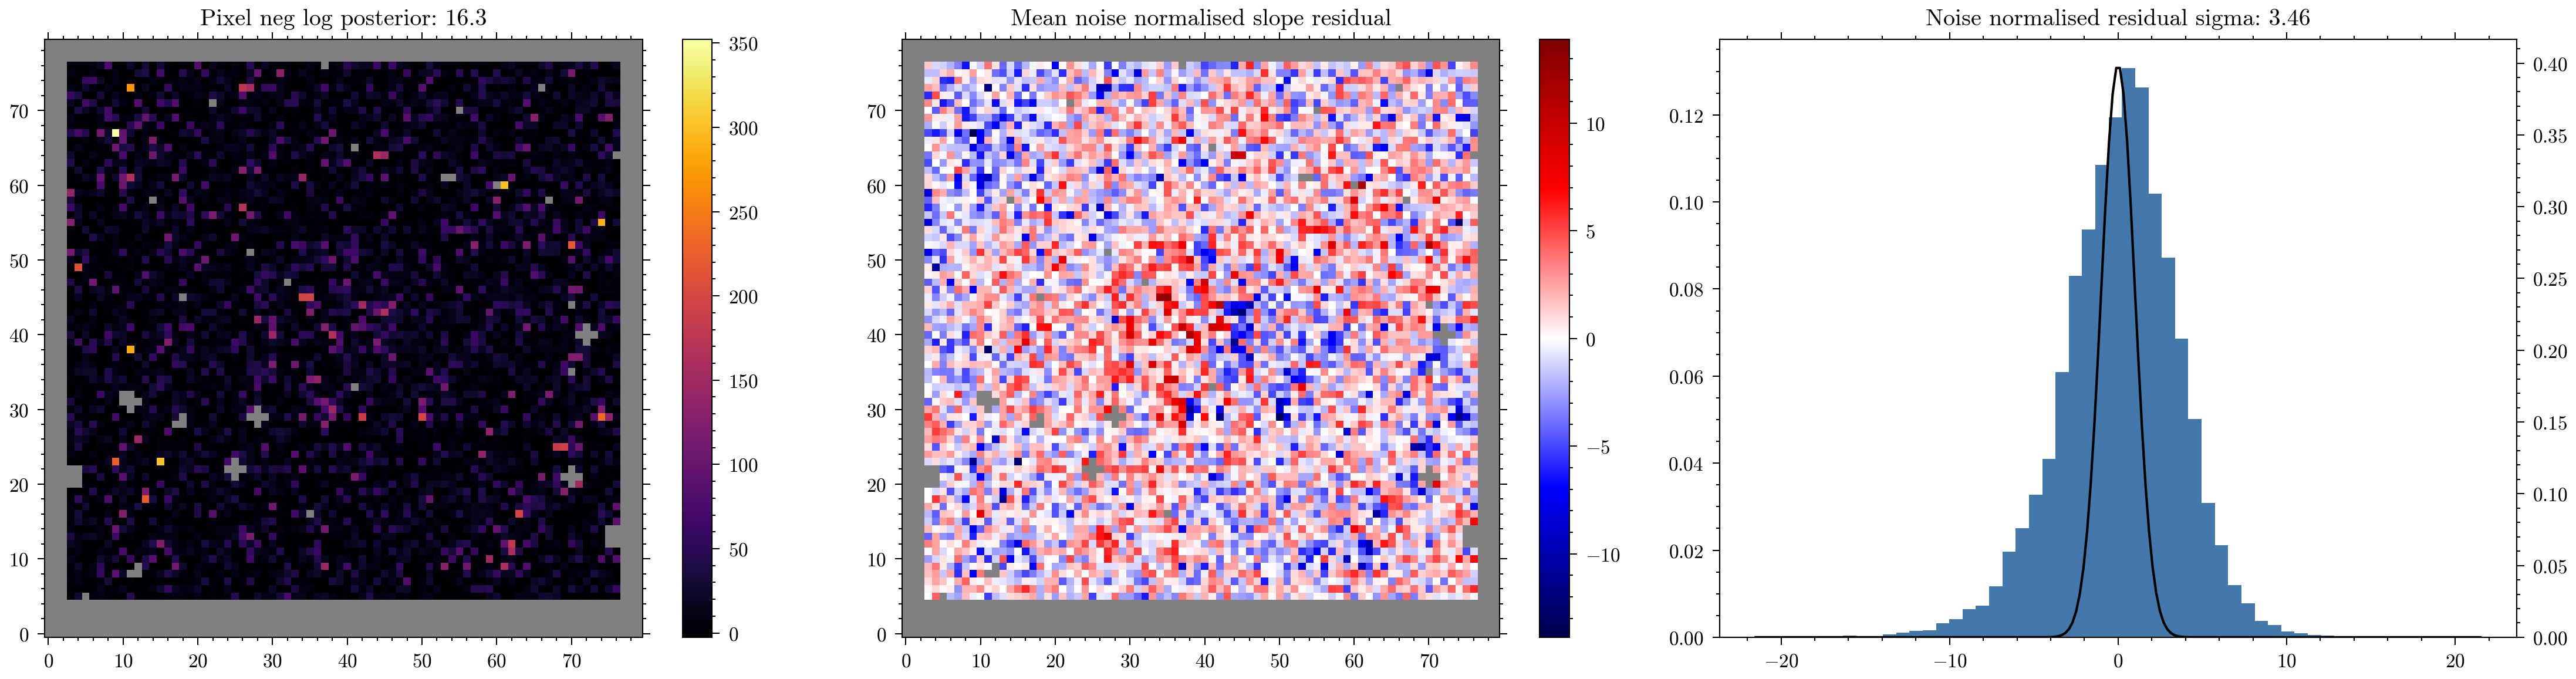

F430M Calibrator HD-18638 5


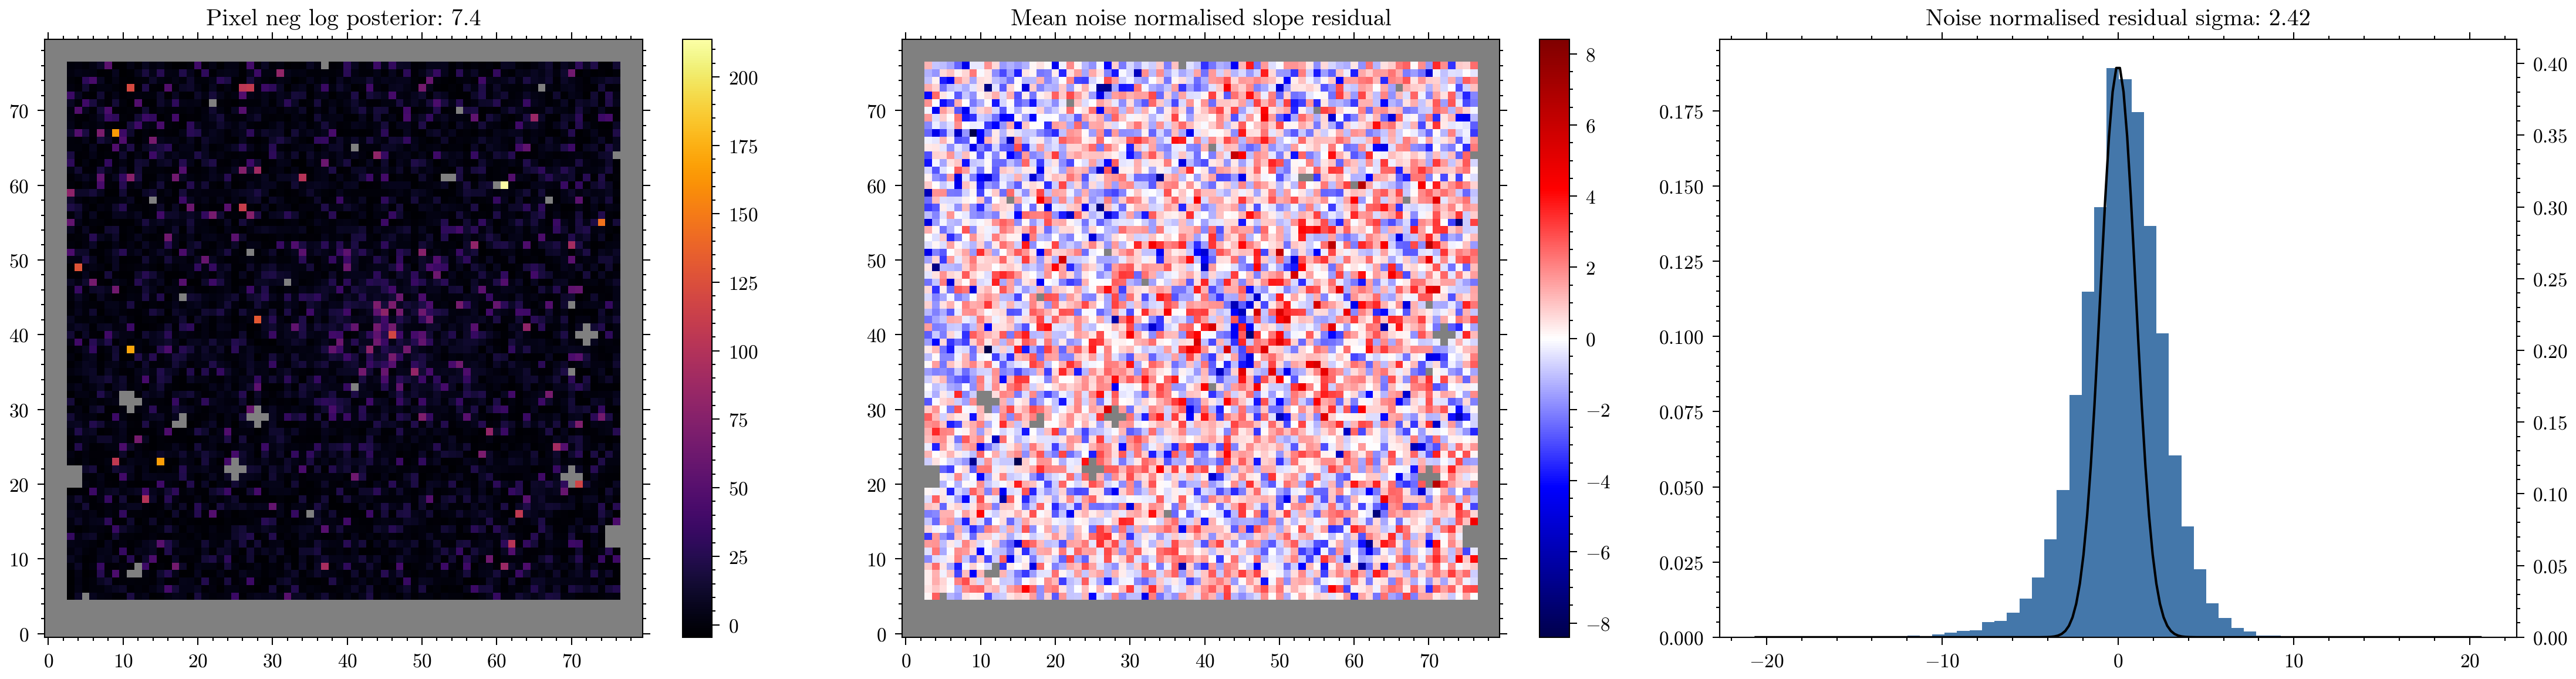

F480M Science NU-HOR 5


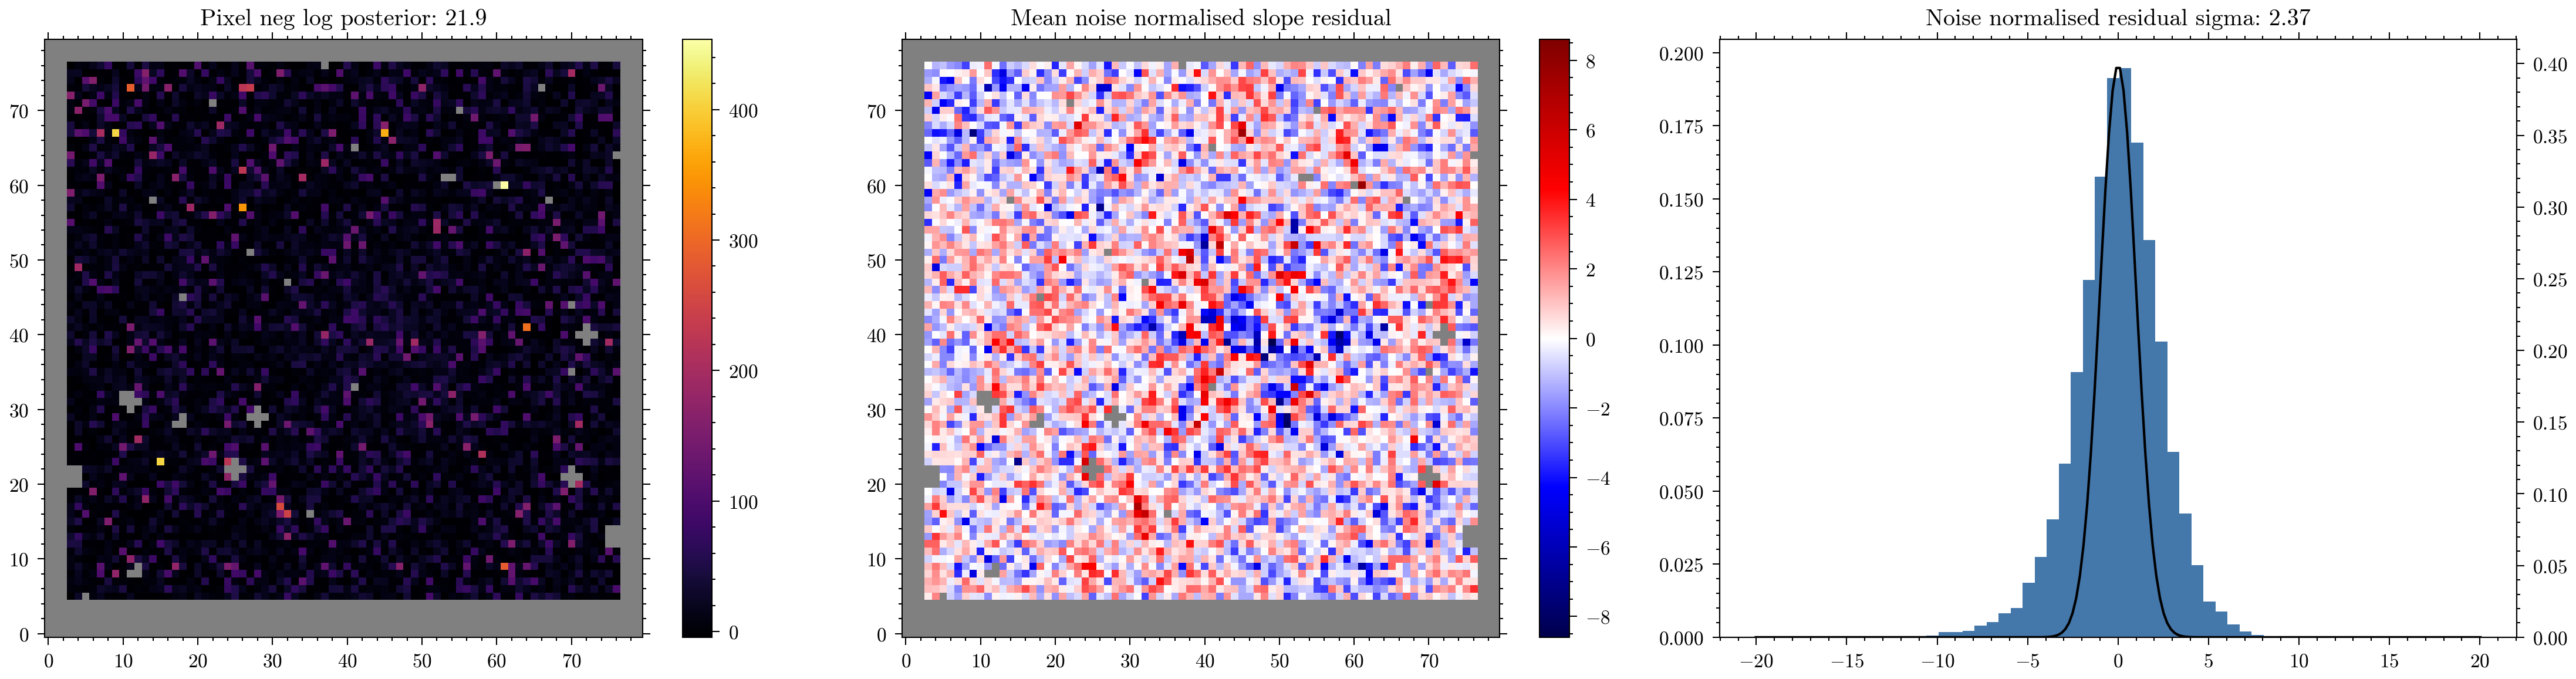

F480M Calibrator HD-18638 8


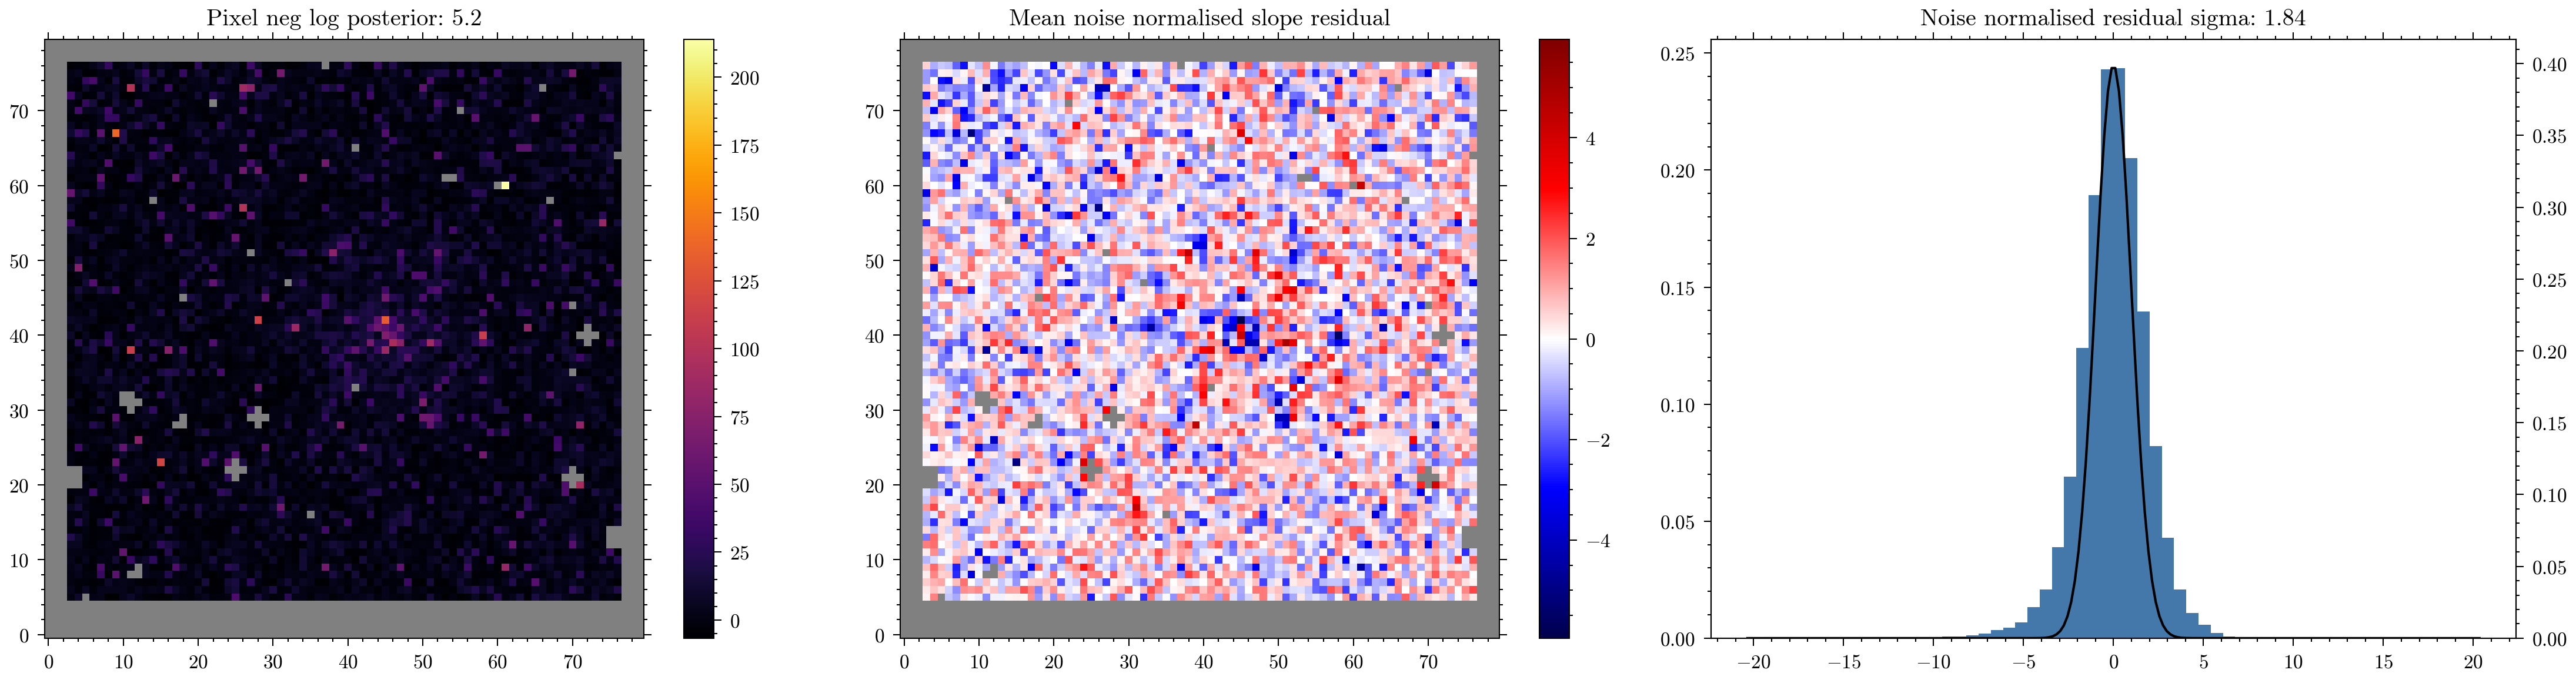

: 

In [ ]:
np.save("files/NUHOR_CAL.npy", final_model.params, allow_pickle=True)

for filt in ["F380M", "F430M", "F480M"]:
    for exp in exps:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

# NumPyro

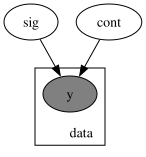

In [ ]:
import numpyro, chainconsumer


def npy_model(model, exposure):
    # sampling params
    stdev = numpyro.sample("sig", numpyro.distributions.HalfNormal(1))  # prior on m
    contrast = numpyro.sample("cont", numpyro.distributions.HalfNormal(1))  # Prior on c

    # updating model with sampled params
    params = model.params
    params["stdev"][exposure.get_key("stdev")] = stdev
    params["contrast"][exposure.get_key("contrast")] = contrast
    model.set("params", params)

    # laying out the components
    data = exposure.slopes.flatten()
    X = exposure(model).flatten()
    err = np.einsum("iixy->ixy", exposure.cov).flatten()  # the diagonal of the cov mats

    with numpyro.plate("data", data.size):
        numpyro.sample("y", numpyro.distributions.Normal(X, err), obs=data)


numpyro.render_model(npy_model, model_args=(result.model, exps[0]))

In [12]:
sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(npy_model), num_chains=1, num_samples=3, num_warmup=0
)
sampler.run(jax.random.PRNGKey(1), model, exps[0])

sample: 100%|██████████| 3/3 [00:13<00:00,  4.56s/it, 1 steps of size 1.00e+00. acc. prob=0.00]


,cont,sig
0,0.668504,0.144144
1,0.668504,0.144144
2,0.668504,0.144144


In [24]:
import chainconsumer as cc, pandas as pd

results = sampler.get_samples()  # Dictionary of MCMC samples
C = cc.ChainConsumer()
# cc.Chain(pd.DataFrame(results))
# C.plotter.plot(
#     extents={'m': [-5,5], 'c':[-10,10]},
#     truth = {'m':m_true, 'c':c_true})

# plt.show()

In [29]:
pd.DataFrame(results)

,cont,sig
0,0.668504,0.144144
1,0.668504,0.144144
2,0.668504,0.144144


In [30]:
df

,A,B,log_posterior
0,-0.666653,3.207928,-3.589963
1,-1.080682,5.376272,-2.521296
2,1.283445,6.709301,-3.979911
3,-0.275509,3.969396,-2.387709
4,1.112396,4.550631,-2.592965
...,...,...,...
999995,0.623101,5.084616,-2.030542
999996,0.389066,4.955407,-1.913764
999997,0.429381,5.151106,-1.935157
999998,-0.085414,3.867107,-2.477284


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/chainconsumer/plotter.py:862: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(base.extents[p2])
/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/chainconsumer/plotter.py:861: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(base.extents[p1])
/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


IndexError: index 0 is out of bounds for axis 0 with size 0

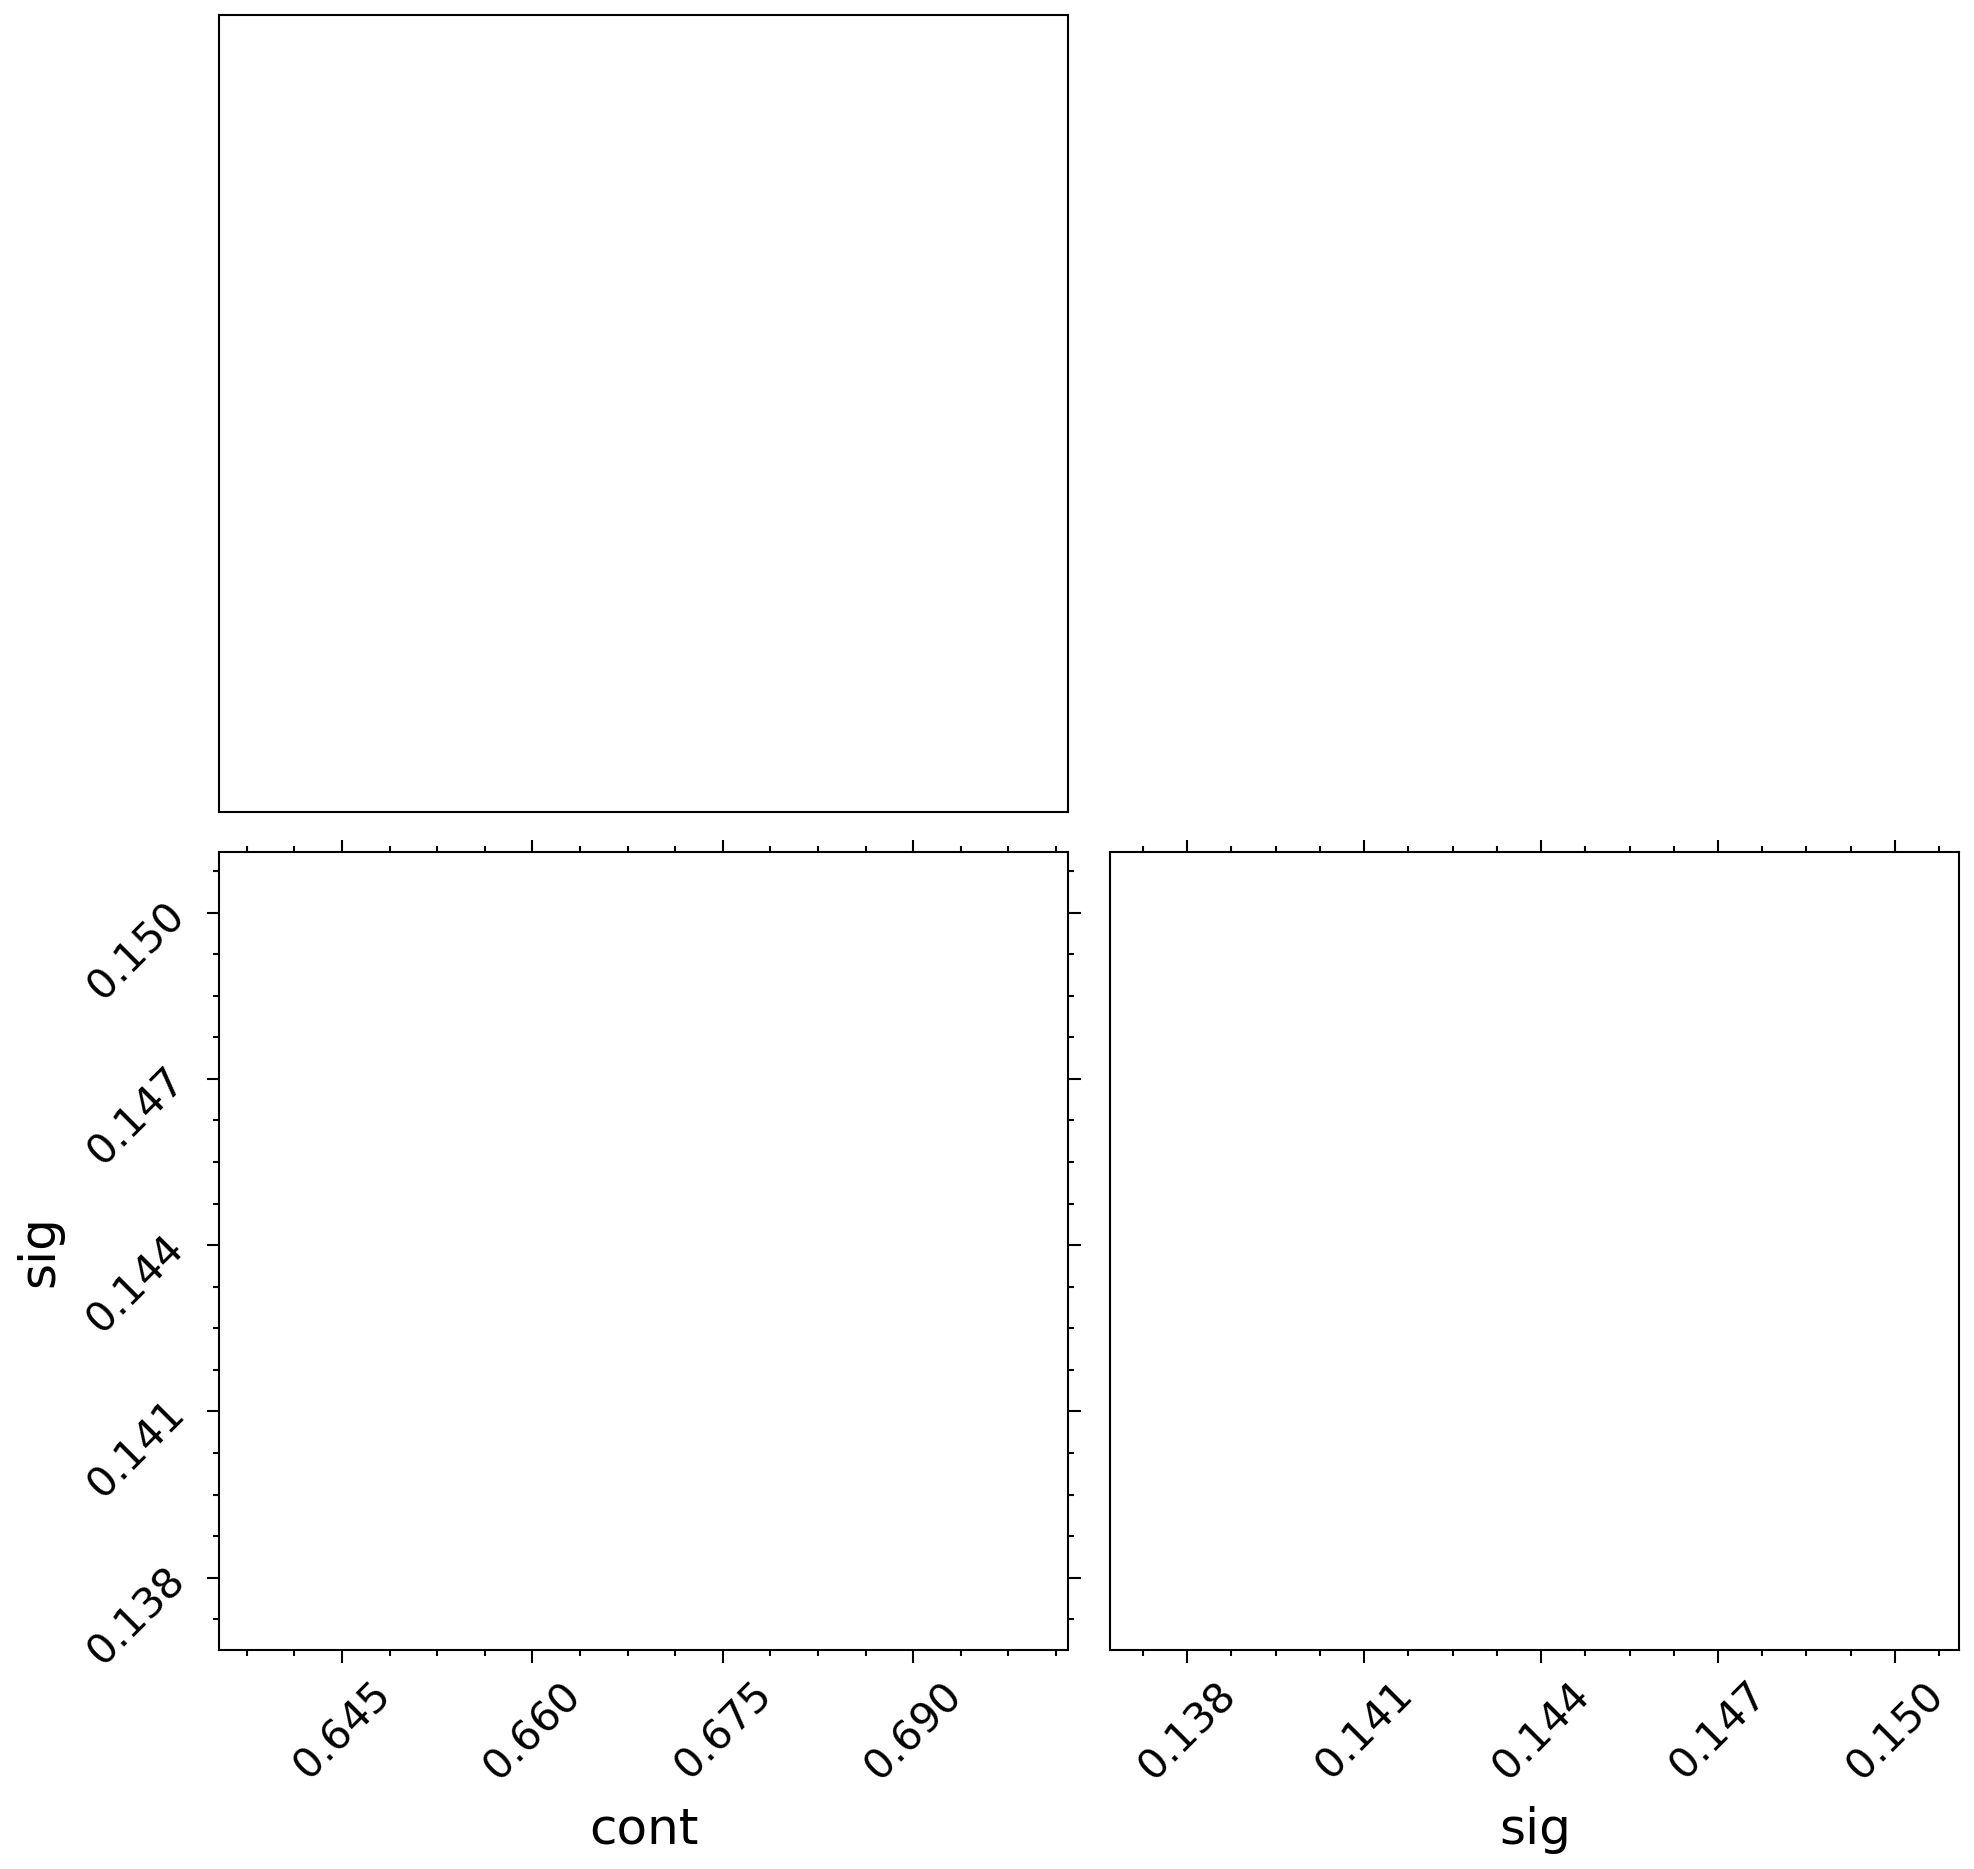

In [31]:
from chainconsumer import Chain, ChainConsumer, make_sample


df = pd.DataFrame(results)
c = ChainConsumer()
c.add_chain(Chain(samples=df, name="An Example Contour"))
fig = c.plotter.plot()